In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/User/Desktop/AML_Lab/UnivariantGaussian/marketing_campaign.csv",sep=';')

print(df.head())
print(df.shape)


     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [14]:
df = df.dropna()


In [15]:
features = df[[
    'Income',
    'Recency',
    'NumWebPurchases',
    'NumStorePurchases',
    'NumCatalogPurchases',
    'NumWebVisitsMonth',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts'
]]


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


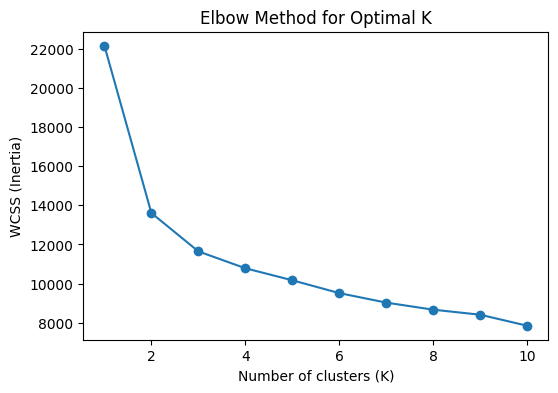

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []   # within-cluster sum of squares

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()


In [20]:
from sklearn.cluster import KMeans
y_kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,n_init=10,random_state=0)
y_k=y_kmeans.fit_predict(X_scaled)

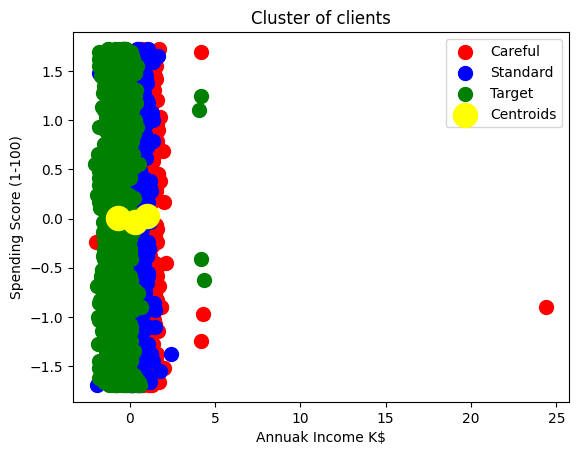

In [21]:
plt.scatter(X_scaled[y_k==0,0],X_scaled[y_k==0,1],s=100,c="red",label='Careful')
plt.scatter(X_scaled[y_k==1,0],X_scaled[y_k==1,1],s=100,c="blue",label='Standard')
plt.scatter(X_scaled[y_k==2,0],X_scaled[y_k==2,1],s=100,c="green",label='Target')
plt.scatter(y_kmeans.cluster_centers_[:,0],y_kmeans.cluster_centers_[:,1],s=300,c='yellow',label="Centroids")

plt.title('Cluster of clients')
plt.xlabel('Annuak Income K$')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()